In [2]:
# Import Libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Load cleaned data:
df = pd.read_csv(
    "../data/processed/telco_customer_churn_clean.csv"
)

In [4]:
df.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,churn_flag
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


In [5]:
# EDA 1 — Overall churn rate
churn_counts = df["churn"].value_counts()

churn_counts

churn
No     5174
Yes    1869
Name: count, dtype: int64

In [6]:
churn_percentage = (
    df["churn"]
    .value_counts(normalize=True)
    .mul(100)
)

churn_percentage

churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

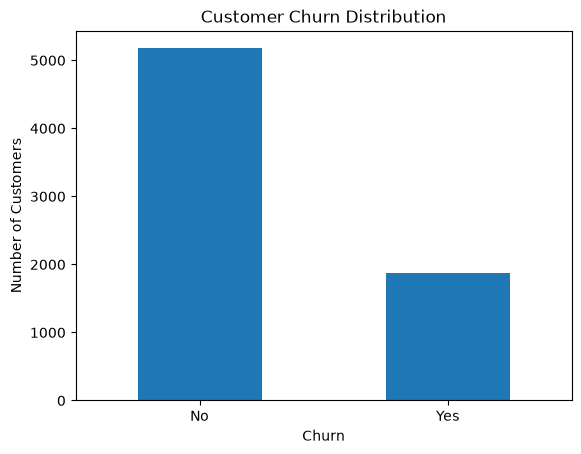

In [7]:
# Creating graph
churn_counts.plot(
    kind="bar"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

**Business insight
Under the graph create a Markdown cell:**

**### Insight

The dataset contains more non-churn customers than churn
customers. Therefore, the target variable is moderately
imbalanced.

Accuracy alone may therefore be misleading, so metrics such as
precision, recall, F1-score, ROC-AUC and PR-AUC should also be
considered.**

In [9]:
# EDA 2 — Churn vs Contract Type
contract_churn = pd.crosstab(
    df["contract"],
    df["churn"],
    normalize="index"
) * 100

contract_churn

churn,No,Yes
contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


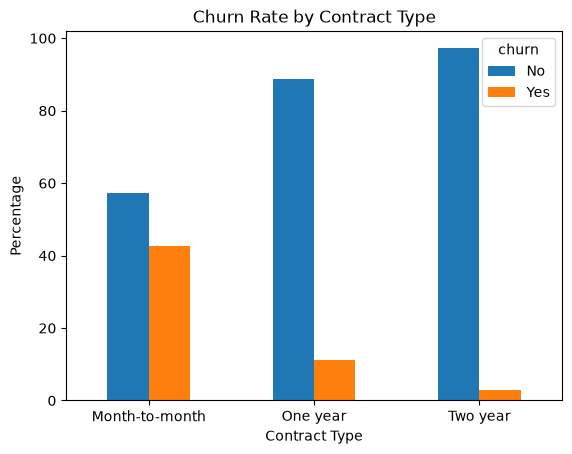

In [10]:
contract_churn.plot(
    kind="bar"
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

In [11]:
# EDA 3 — Churn vs Tenure
df.groupby("churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


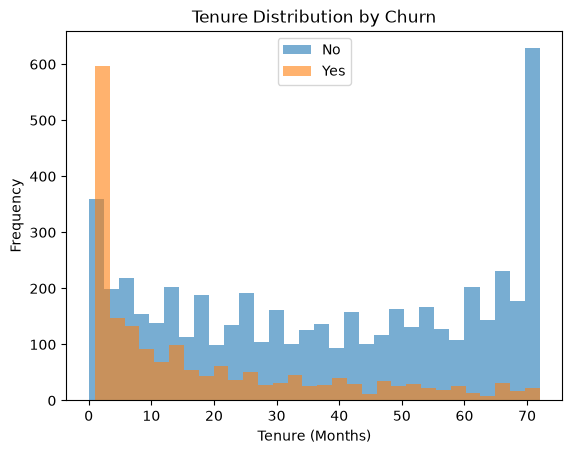

In [12]:
# Creating histogram
df[df["churn"] == "No"]["tenure"].plot(
    kind="hist",
    bins=30,
    alpha=0.6,
    label="No"
)

df[df["churn"] == "Yes"]["tenure"].plot(
    kind="hist",
    bins=30,
    alpha=0.6,
    label="Yes"
)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure (Months)")
plt.legend()
plt.show()

In [ ]:
# Creating tenure groups for EDA process
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[-1, 6, 12, 24, 48, 72],
    labels=[
        "0-6 months",
        "7-12 months",
        "13-24 months",
        "25-48 months",
        "49-72 months"
    ]
)

In [15]:
df["tenure_group"].value_counts()

tenure_group
49-72 months    2239
25-48 months    1594
0-6 months      1481
13-24 months    1024
7-12 months      705
Name: count, dtype: int64

In [16]:
# Now calculate churn rate:
tenure_churn = (
    df.groupby("tenure_group", observed=False)
      ["churn_flag"]
      .mean()
      .mul(100)
)

tenure_churn

tenure_group
0-6 months      52.937205
7-12 months     35.886525
13-24 months    28.710938
25-48 months    20.388959
49-72 months     9.513176
Name: churn_flag, dtype: float64

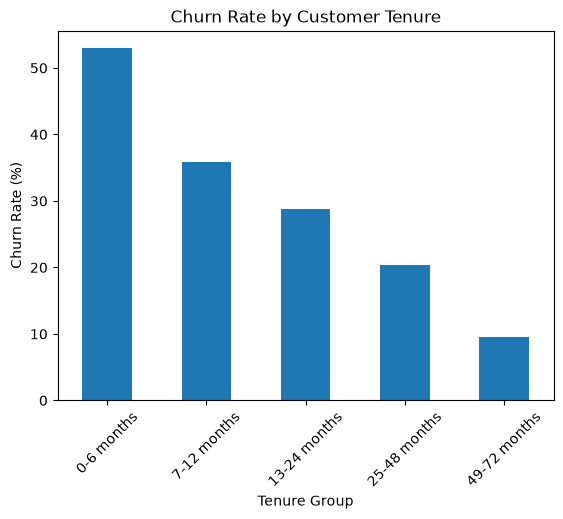

In [17]:
# Plot:
tenure_churn.plot(
    kind="bar"
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)
plt.show()

In [18]:
# EDA 4 — Monthly Charges vs Churn
df.groupby("churn")["monthlycharges"].describe()

,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


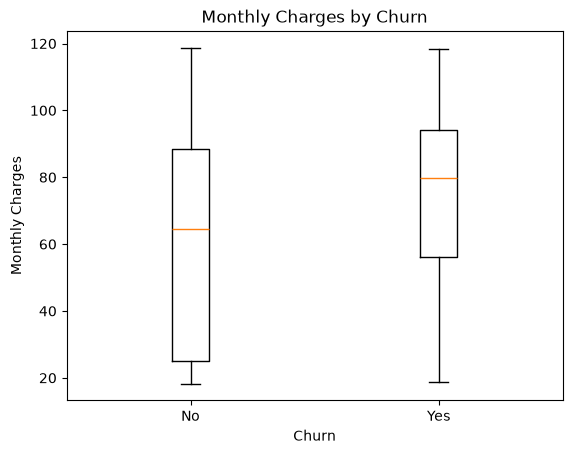

In [ ]:
# Creating boxplot:
data_no = df[df["churn"] == "No"]["monthlycharges"]
data_yes = df[df["churn"] == "Yes"]["monthlycharges"]

plt.boxplot(
    [data_no, data_yes],
    tick_labels=["No", "Yes"]
)

plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

In [21]:
# EDA 5 — Total Charges vs Churn
df.groupby("churn")["totalcharges"].describe()

,count,mean,std,min,25%,50%,75%,max
churn,,,,,,,,
No,5174.0,2549.911442,2329.954215,0.00,572.9,1679.525,4262.85,8672.45
Yes,1869.0,1531.796094,1890.822994,18.85,134.5,703.550,2331.30,8684.80


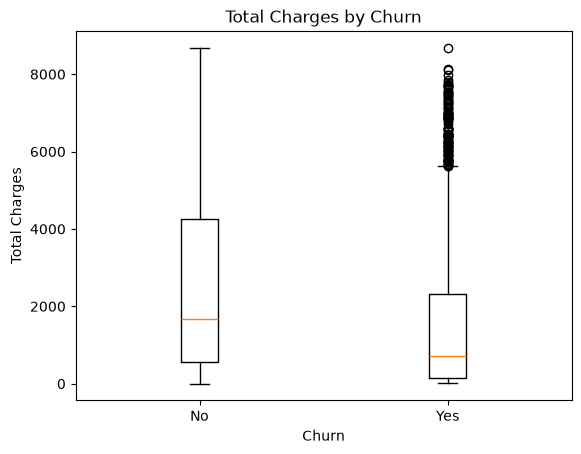

In [23]:
plt.boxplot(
    [
        df[df["churn"] == "No"]["totalcharges"],
        df[df["churn"] == "Yes"]["totalcharges"]
    ],
    tick_labels=["No", "Yes"]
)

plt.title("Total Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Total Charges")
plt.show()

In [24]:
# EDA 6 — Internet Service
internet_churn = pd.crosstab(
    df["internetservice"],
    df["churn"],
    normalize="index"
) * 100

internet_churn

churn,No,Yes
internetservice,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


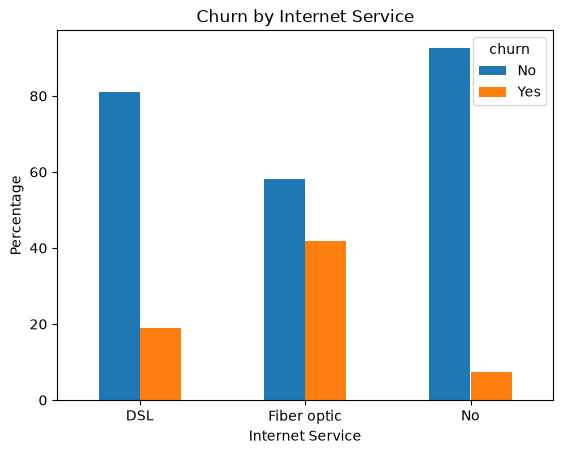

In [25]:
# plot
internet_churn.plot(
    kind="bar"
)

plt.title("Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

In [26]:
# EDA 7 — Tech Support
support_churn = pd.crosstab(
    df["techsupport"],
    df["churn"],
    normalize="index"
) * 100

support_churn

churn,No,Yes
techsupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


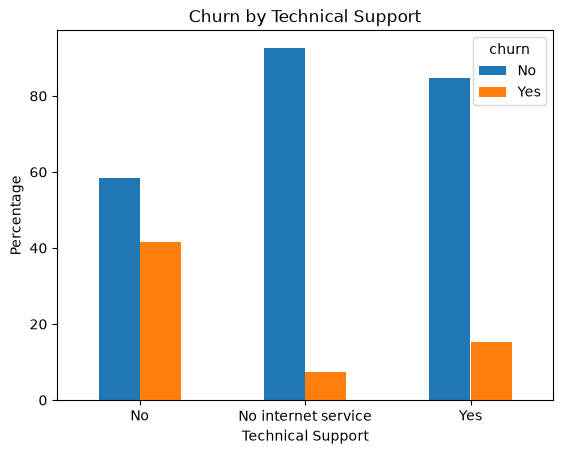

In [27]:
# Plot
support_churn.plot(
    kind="bar"
)

plt.title("Churn by Technical Support")
plt.xlabel("Technical Support")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

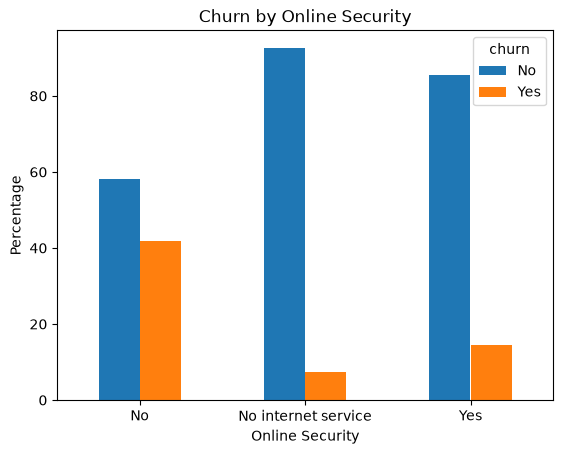

In [28]:
# EDA 8 — Online Security
security_churn = pd.crosstab(
    df["onlinesecurity"],
    df["churn"],
    normalize="index"
) * 100

security_churn.plot(
    kind="bar"
)

plt.title("Churn by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

In [31]:
# EDA 9 — Payment Method
payment_churn = pd.crosstab(
    df["paymentmethod"],
    df["churn"],
    normalize="index"
) * 100

payment_churn

churn,No,Yes
paymentmethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


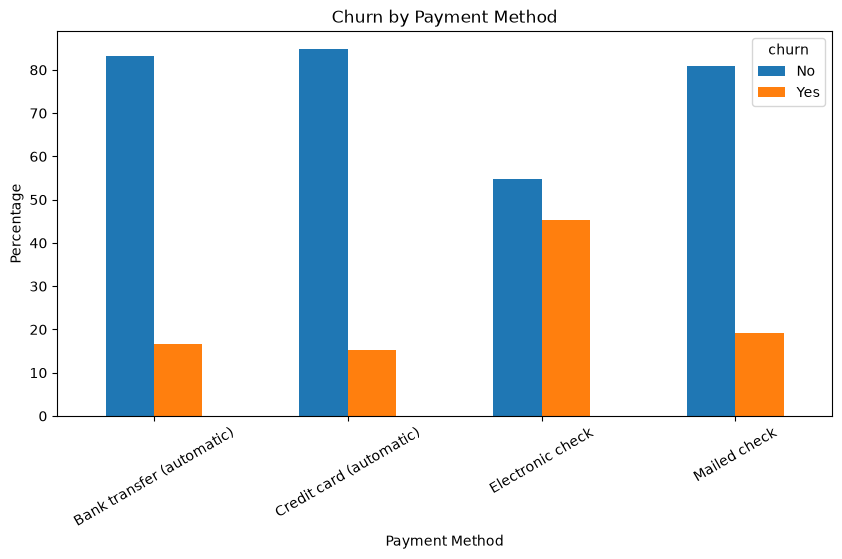

In [32]:
payment_churn.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Percentage")
plt.xticks(rotation=30)
plt.show()

In [33]:
# EDA 10 — Paperless Billing
paperless_churn = pd.crosstab(
    df["paperlessbilling"],
    df["churn"],
    normalize="index"
) * 100

paperless_churn

churn,No,Yes
paperlessbilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092


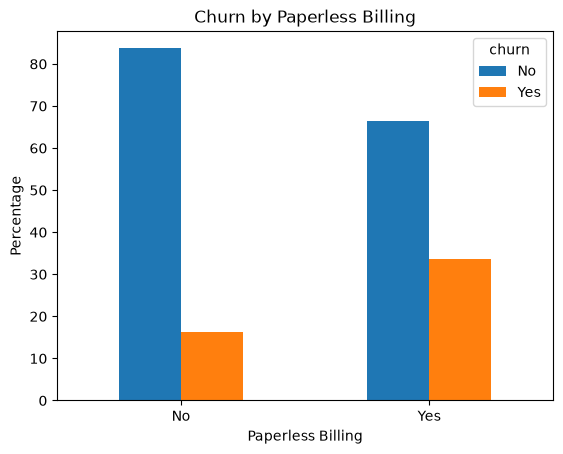

In [34]:
# graph
paperless_churn.plot(
    kind="bar"
)

plt.title("Churn by Paperless Billing")
plt.xlabel("Paperless Billing")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

In [35]:
# EDA 11 — Senior Citizens
senior_churn = pd.crosstab(
    df["seniorcitizen"],
    df["churn"],
    normalize="index"
) * 100

senior_churn

churn,No,Yes
seniorcitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


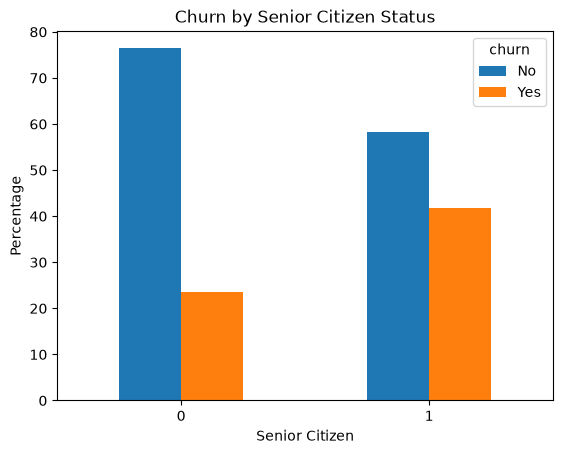

In [36]:
# graph
senior_churn.plot(
    kind="bar"
)

plt.title("Churn by Senior Citizen Status")
plt.xlabel("Senior Citizen")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

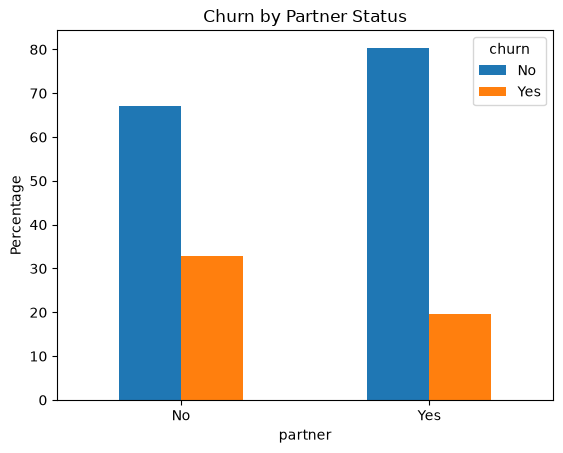

In [38]:
# EDA 12 — Partner
partner_churn = pd.crosstab(
    df["partner"],
    df["churn"],
    normalize="index"
) * 100

partner_churn.plot(
    kind="bar"
)

plt.title("Churn by Partner Status")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

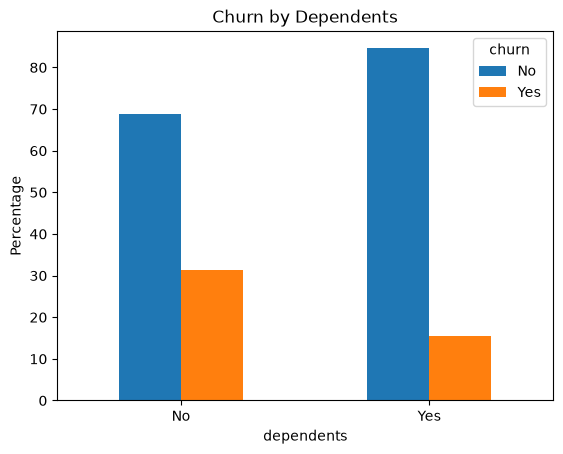

In [40]:
# EDA 13 — Dependents
dependents_churn = pd.crosstab(
    df["dependents"],
    df["churn"],
    normalize="index"
) * 100

dependents_churn.plot(
    kind="bar"
)

plt.title("Churn by Dependents")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

In [41]:
# EDA 14 — Gender
gender_churn = pd.crosstab(
    df["gender"],
    df["churn"],
    normalize="index"
) * 100

gender_churn

churn,No,Yes
gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


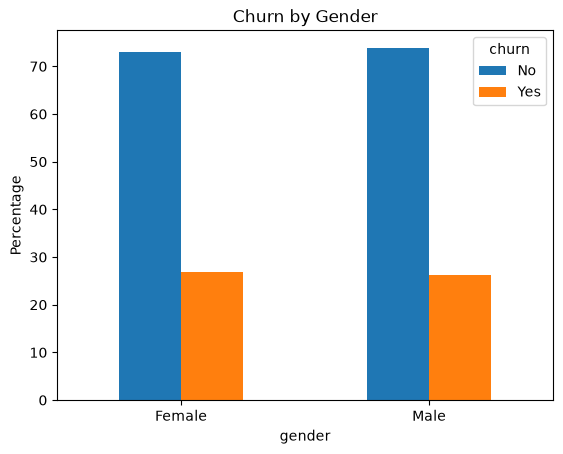

In [42]:
# Graph:
gender_churn.plot(
    kind="bar"
)

plt.title("Churn by Gender")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.show()

In [43]:
# EDA 15 — All categorical features automatically
def churn_rate_by_category(data, column):
    result = (
        data.groupby(column)["churn_flag"]
        .mean()
        .mul(100)
        .sort_values(ascending=False)
    )
    
    print(result)
    
    result.plot(
        kind="bar",
        figsize=(8, 4)
    )
    
    plt.title(f"Churn Rate by {column}")
    plt.xlabel(column)
    plt.ylabel("Churn Rate (%)")
    plt.xticks(rotation=45)
    plt.show()

contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: churn_flag, dtype: float64


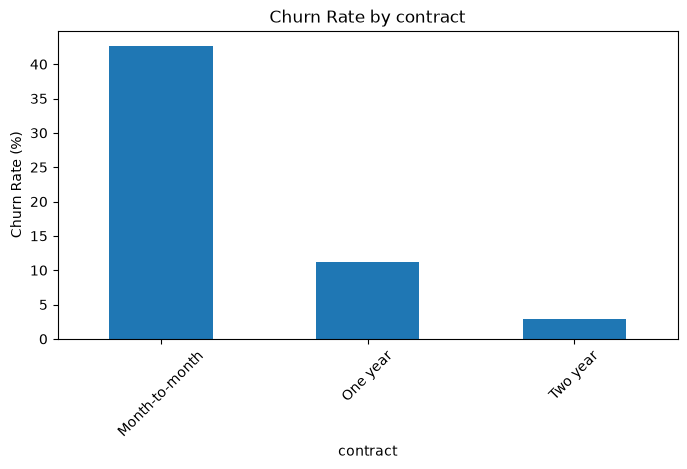

In [44]:
churn_rate_by_category(
    df,
    "contract"
)

internetservice
Fiber optic    41.892765
DSL            18.959108
No              7.404980
Name: churn_flag, dtype: float64


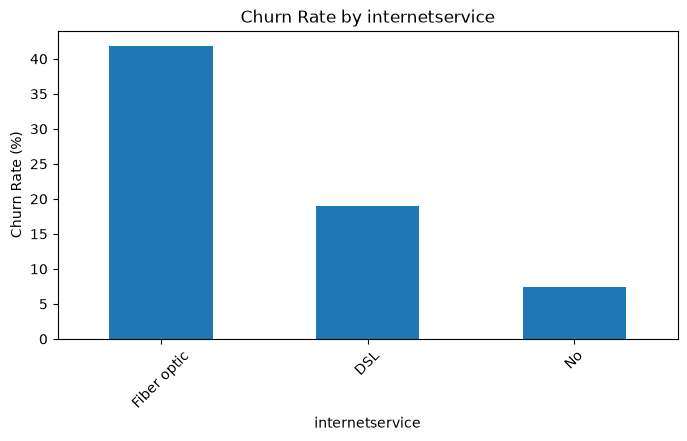

In [45]:
churn_rate_by_category(
    df,
    "internetservice"
)

paymentmethod
Electronic check             45.285412
Mailed check                 19.106700
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Name: churn_flag, dtype: float64


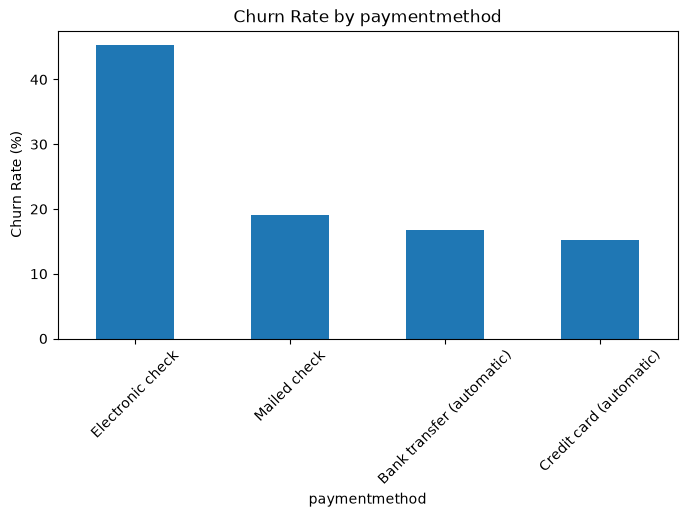

In [46]:
churn_rate_by_category(
    df,
    "paymentmethod"
)

In [47]:
# EDA 16 — Numeric correlations
numeric_df = df[
    [
        "seniorcitizen",
        "tenure",
        "monthlycharges",
        "totalcharges",
        "churn_flag"
    ]
]

In [48]:
# Calculate
correlation = numeric_df.corr()

correlation

,seniorcitizen,tenure,monthlycharges,totalcharges,churn_flag
seniorcitizen,1.000000,0.016567,0.220173,0.103006,0.150889
tenure,0.016567,1.000000,0.247900,0.826178,-0.352229
monthlycharges,0.220173,0.247900,1.000000,0.651174,0.193356
totalcharges,0.103006,0.826178,0.651174,1.000000,-0.198324
churn_flag,0.150889,-0.352229,0.193356,-0.198324,1.000000


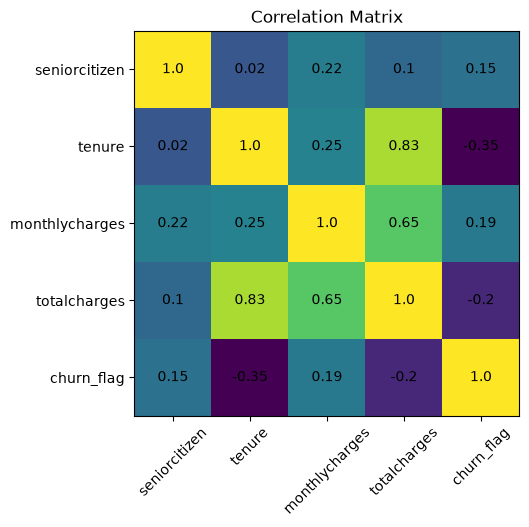

In [49]:
# We can visualize it without extra libraries:
fig, ax = plt.subplots(figsize=(7, 5))

image = ax.imshow(correlation)

ax.set_xticks(range(len(correlation.columns)))
ax.set_yticks(range(len(correlation.columns)))

ax.set_xticklabels(
    correlation.columns,
    rotation=45
)

ax.set_yticklabels(
    correlation.columns
)

for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):
        ax.text(
            j,
            i,
            round(correlation.iloc[i, j], 2),
            ha="center",
            va="center"
        )

plt.title("Correlation Matrix")
plt.show()

In [50]:
# EDA 17 — Contract + Tenure together
contract_tenure = (
    df.groupby(["contract", "churn"])
      ["tenure"]
      .mean()
)

contract_tenure

contract        churn
Month-to-month  No       21.033333
                Yes      14.016918
One year        No       41.674063
                Yes      44.963855
Two year        No       56.602914
                Yes      61.270833
Name: tenure, dtype: float64

In [51]:
# EDA 18 — Contract + Monthly Charges
df.groupby(
    ["contract", "churn"]
)["monthlycharges"].mean()

contract        churn
Month-to-month  No       61.462635
                Yes      73.019396
One year        No       62.508148
                Yes      85.050904
Two year        No       60.012477
                Yes      86.777083
Name: monthlycharges, dtype: float64

In [52]:
# EDA 19 — Internet Service + Contract
interaction = (
    df.groupby(
        ["internetservice", "contract"]
    )["churn_flag"]
    .mean()
    .mul(100)
)

interaction

internetservice  contract      
DSL              Month-to-month    32.215863
                 One year           9.298246
                 Two year           1.910828
Fiber optic      Month-to-month    54.605263
                 One year          19.294991
                 Two year           7.226107
No               Month-to-month    18.893130
                 One year           2.472527
                 Two year           0.783699
Name: churn_flag, dtype: float64

In [53]:
# converting it into a table:
interaction_table = (
    df.pivot_table(
        values="churn_flag",
        index="internetservice",
        columns="contract",
        aggfunc="mean"
    ) * 100
)

interaction_table

contract,Month-to-month,One year,Two year
internetservice,,,
DSL,32.215863,9.298246,1.910828
Fiber optic,54.605263,19.294991,7.226107
No,18.893130,2.472527,0.783699


In [54]:
# EDA 20 — Customer segmentation
def customer_segment(row):
    if row["tenure"] <= 12:
        return "New Customer"
    elif row["tenure"] <= 36:
        return "Growing Customer"
    elif row["tenure"] <= 60:
        return "Established Customer"
    else:
        return "Loyal Customer"

In [55]:
df["customer_segment"] = df.apply(
    customer_segment,
    axis=1
)

In [56]:
segment_churn = (
    df.groupby("customer_segment")
      ["churn_flag"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

segment_churn

customer_segment
New Customer            47.438243
Growing Customer        25.538793
Established Customer    16.624843
Loyal Customer           6.609808
Name: churn_flag, dtype: float64

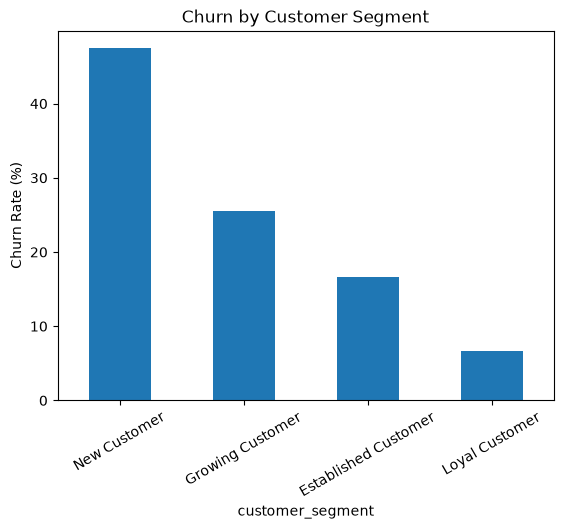

In [57]:
# Plot
segment_churn.plot(
    kind="bar"
)

plt.title("Churn by Customer Segment")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30)
plt.show()

# EDA summary

**# EDA Summary

## Key Findings

1. The target variable is moderately imbalanced.

2. Month-to-month customers show substantially higher churn
   than customers with one-year or two-year contracts.

3. Customers with lower tenure appear more likely to churn.

4. Monthly charges appear to be higher among churned customers.

5. Internet-service type shows meaningful differences in churn.

6. Customers without technical support appear more likely to churn.

7. Payment method is associated with different churn rates.

8. Certain demographic characteristics may have weaker predictive
   value than account and service-related variables.

9. TotalCharges is strongly related to customer tenure and should be
   interpreted carefully.

10. Interactions between contract type, internet service, tenure and
    monthly charges may provide useful predictive information.**